# Sign Language Detection Model

## Project Objective

The objective of this project is to develop a machine learning system that recognizes **American Sign Language (ASL) alphabet gestures** and identifies selected known words using predicted signs.

The system recognizes sign language gestures from uploaded images and webcam/video input. It also operates only during a specified time period, such as **6 PM to 10 PM**.

## Features

- Sign Language Recognition using CNN
- ASL Alphabet Recognition (A–Z)
- Recognition of `space`, `del`, and `nothing`
- Known Word Recognition using predicted letters
- Real-time Webcam/Video Processing
- Image Upload and Prediction
- Time-Based Operation (6 PM–10 PM)
- Gradio GUI Interface
- Model Evaluation and Visualizations
- Accuracy and Loss Graphs
- Confusion Matrix
- Classification Report

## Problem Statement

The task is to train a machine learning model that predicts **sign language gestures** and recognizes some known words of choice.

### Required Logic

1. Accept a sign language image from the user.
2. Predict the corresponding ASL alphabet/sign using a CNN model.
3. Recognize selected known words by combining predicted letters.
4. Support both **image upload and webcam/real-time video input**.
5. Allow the system to operate only during the specified time period, such as **6 PM to 10 PM**.
6. Display the predicted sign, confidence, and recognized word through the GUI.

## Dataset Description

### ASL Alphabet Dataset

This project uses the **ASL Alphabet Dataset** from Kaggle.

The dataset contains **29 classes**:

- A–Z
- `del`
- `nothing`
- `space`

The images are processed and resized to **128 × 128 RGB images** before being used for CNN training.

The same ASL dataset is used throughout the project for sign-language recognition and the additional word-recognition functionality.

## Setup

In [1]:
!pip install -q gradio openpyxl

In [2]:
import os
import datetime
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization,
    Rescaling, RandomRotation, RandomZoom, RandomTranslation
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

import gradio as gr

import warnings
warnings.filterwarnings('ignore')

##  Load the data

Using the [ASL Alphabet](https://www.kaggle.com/datasets/grassknoted/asl-alphabet) dataset - one folder per letter A-Z (including J and Z), plus `space`, `del`, and `nothing` folders for the control gestures.

In [3]:
DATA_DIR = '/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train'
gesture_classes = sorted(os.listdir(DATA_DIR))
print('Found', len(gesture_classes), 'classes:', gesture_classes)

Found 29 classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


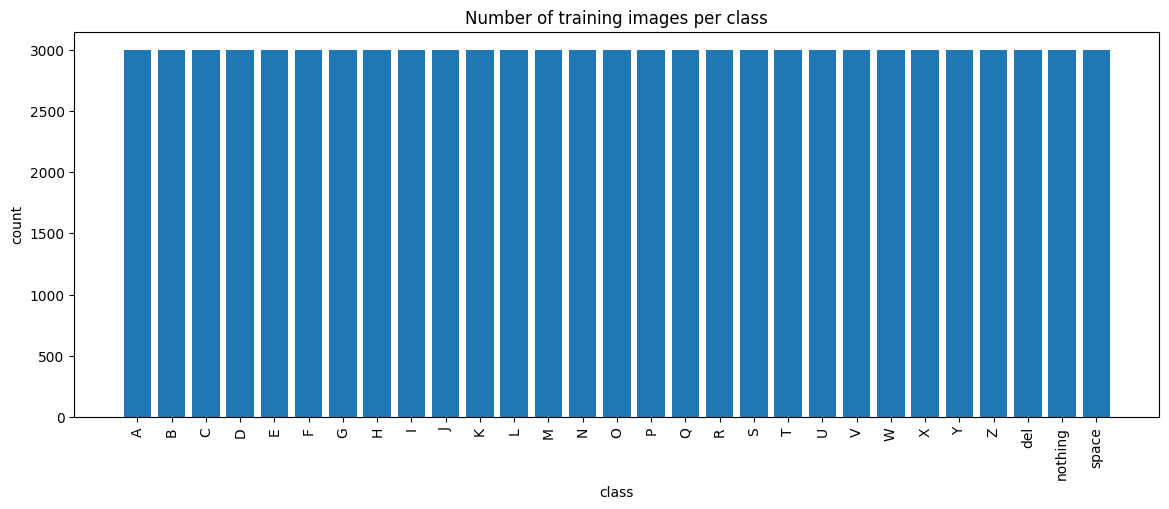

In [4]:
counts = {c: len(os.listdir(os.path.join(DATA_DIR, c))) for c in gesture_classes}

plt.figure(figsize=(14,5))
plt.bar(counts.keys(), counts.values())
plt.title('Number of training images per class')
plt.xlabel('class')
plt.ylabel('count')
plt.xticks(rotation=90)
plt.show()

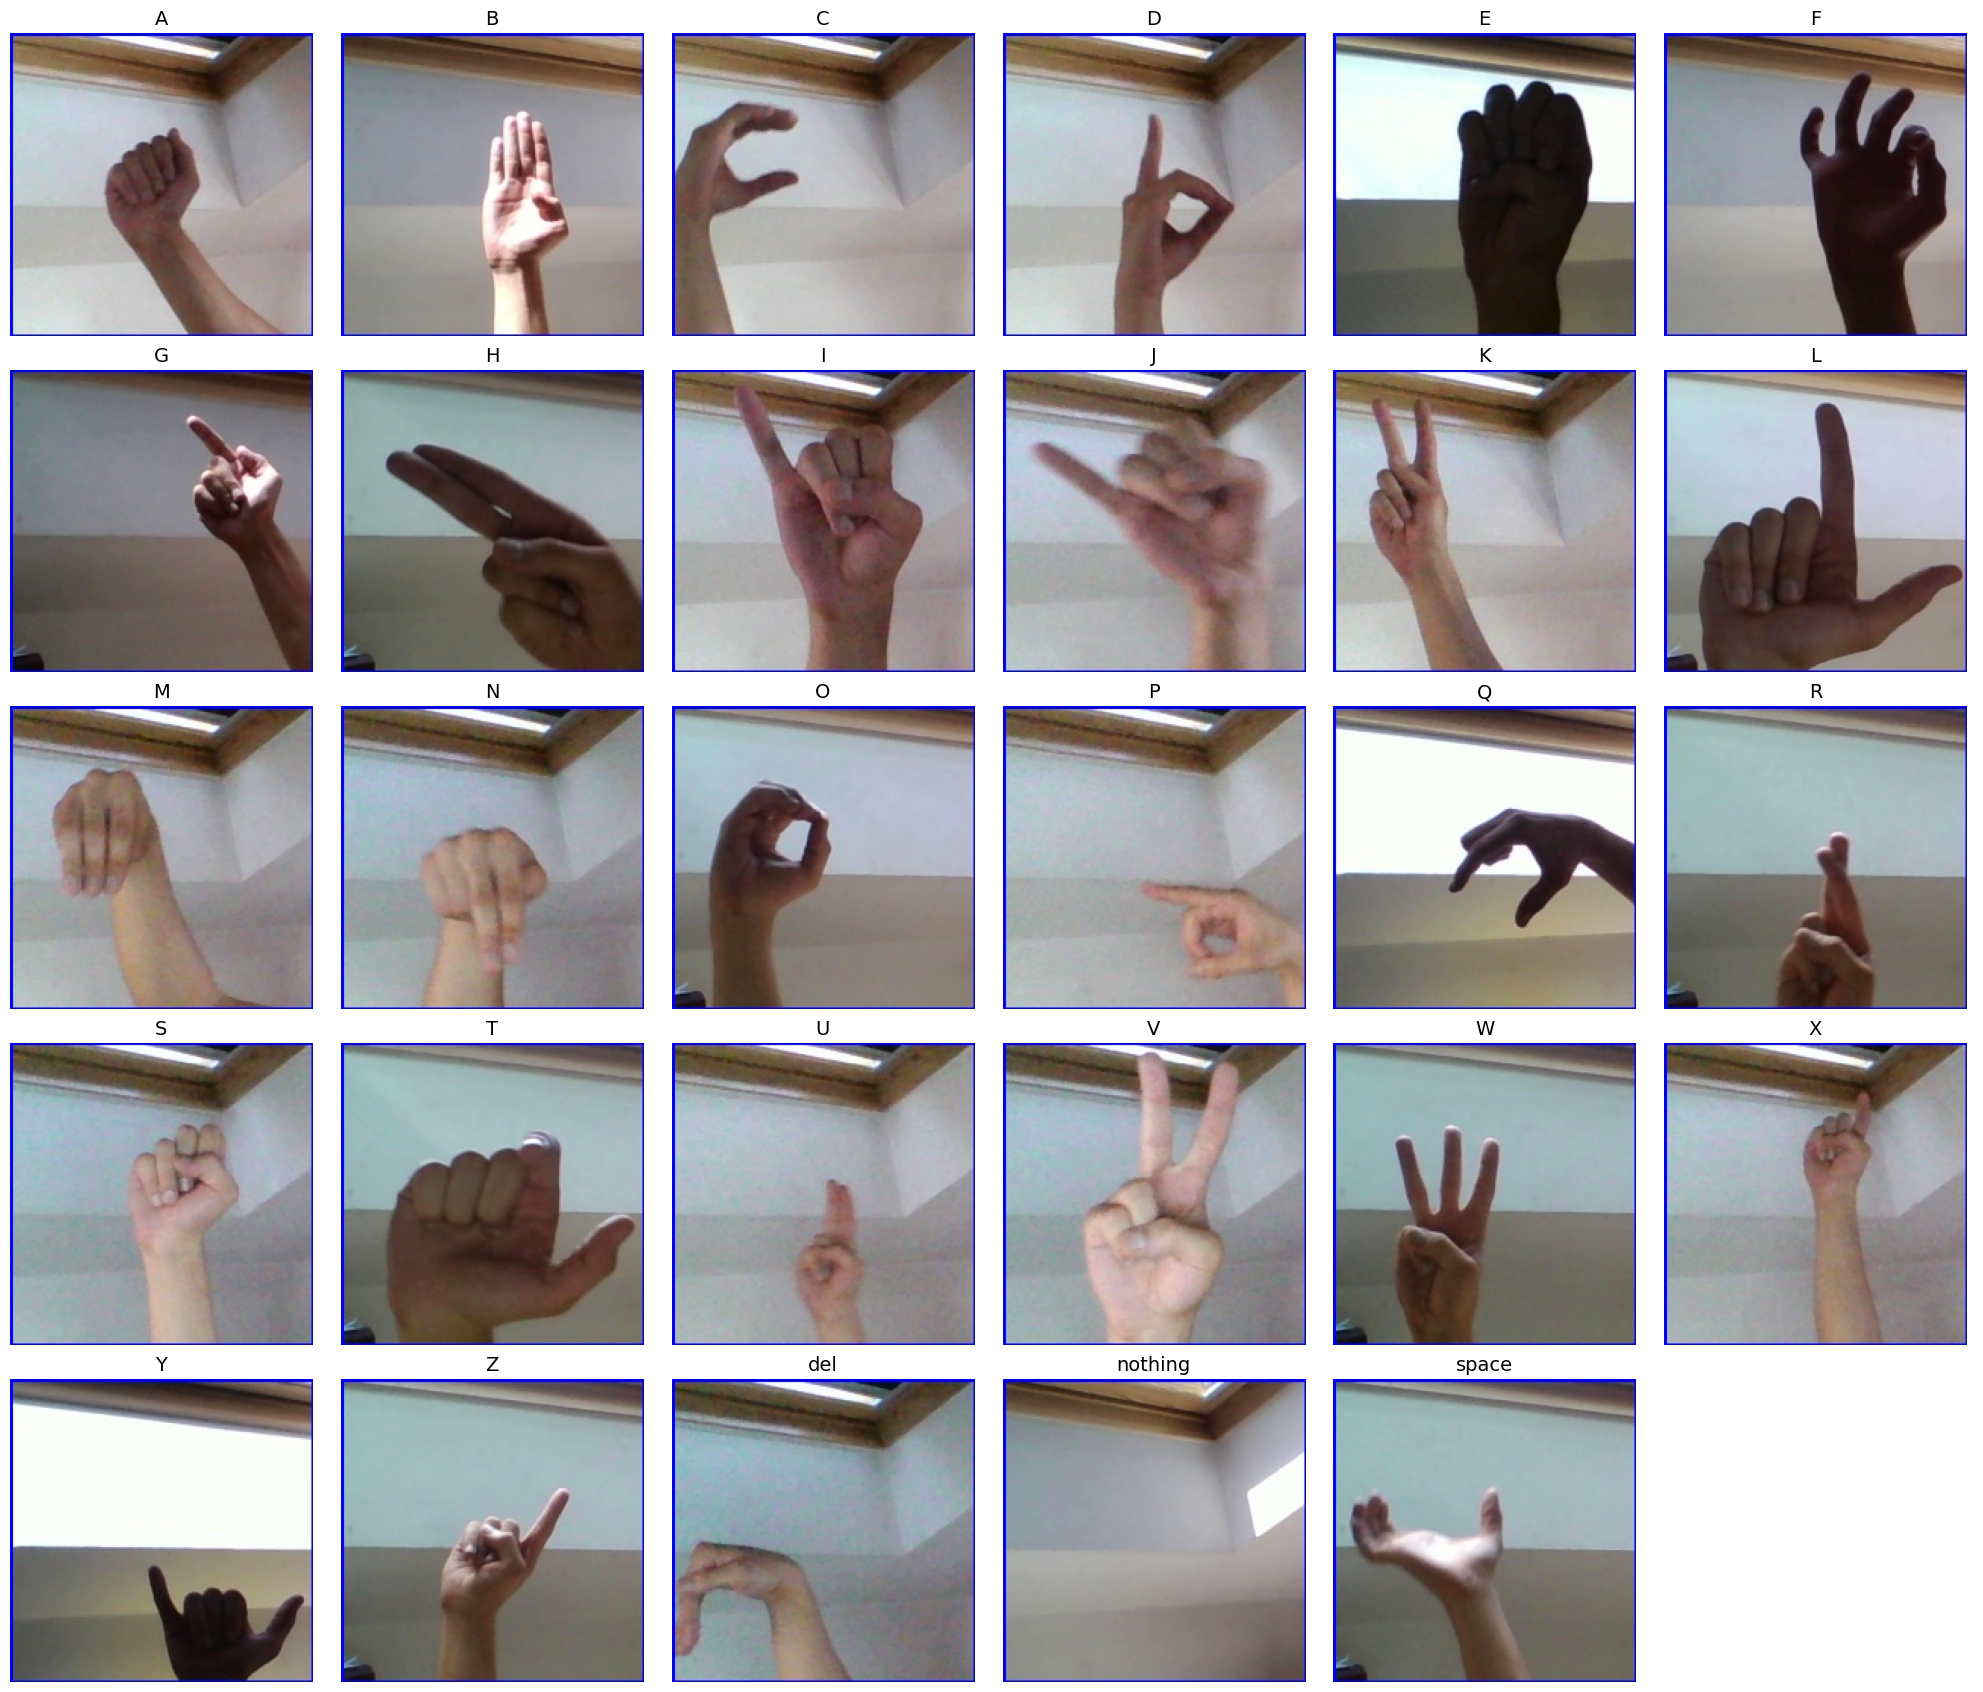

In [5]:
fig, axes = plt.subplots(5, 6, figsize=(20, 17))
for ax, c in zip(axes.flat, gesture_classes):
    class_dir = os.path.join(DATA_DIR, c)
    example_file = os.listdir(class_dir)[0]
    img = cv2.imread(os.path.join(class_dir, example_file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(c, fontsize=14)
    ax.axis('off')

for ax in axes.flat[len(gesture_classes):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Letter sequences for the known words

Exactly which letters to sign, in order, to spell out each word the real-time tab recognizes (`KNOWN_WORDS` in the GUI section below). Each image is a real example photo from the dataset for that letter.

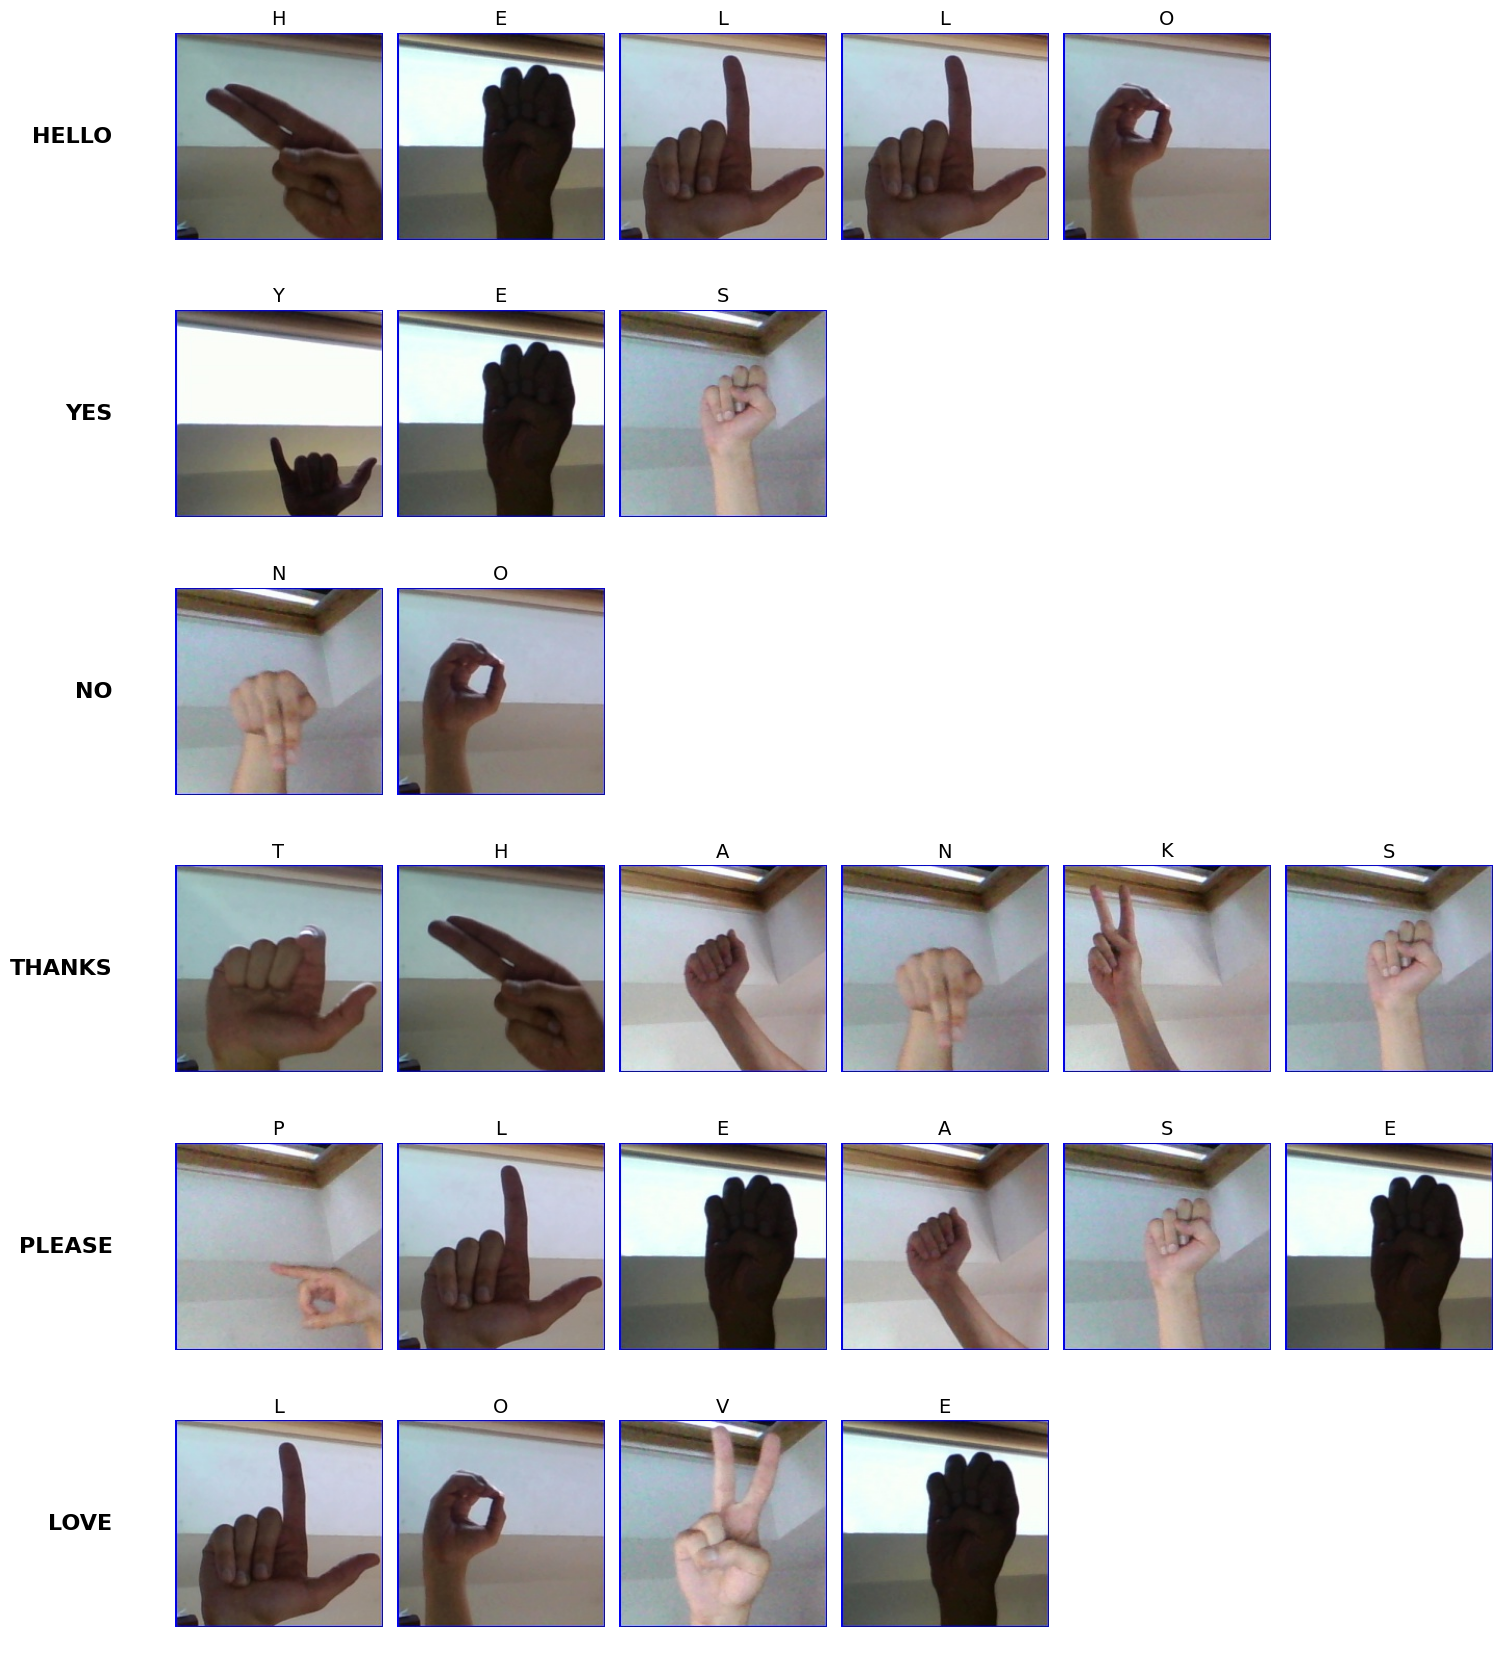

In [6]:
words_to_show = ["HELLO", "YES", "NO", "THANKS", "PLEASE", "LOVE"]  # keep in sync with KNOWN_WORDS below
max_len = max(len(w) for w in words_to_show)

fig, axes = plt.subplots(len(words_to_show), max_len, figsize=(max_len * 2.5, len(words_to_show) * 2.8))

for row, word in enumerate(words_to_show):
    for col in range(max_len):
        ax = axes[row, col]
        ax.axis('off')
        if col < len(word):
            letter = word[col]
            class_dir = os.path.join(DATA_DIR, letter)
            example_file = os.listdir(class_dir)[0]
            img = cv2.imread(os.path.join(class_dir, example_file))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(letter, fontsize=14)
    axes[row, 0].text(-0.3, 0.5, word, transform=axes[row, 0].transAxes,
                       fontsize=16, fontweight='bold', ha='right', va='center')

plt.tight_layout()
plt.show()

## Set up the data pipeline



In [7]:
IMG_SIZE = 128  
BATCH_SIZE = 64
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=gesture_classes,
    color_mode='rgb',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset='training',
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=gesture_classes,
    color_mode='rgb',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset='validation',
    seed=SEED
)

class_names = train_ds.class_names

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

print(class_names)

Found 87000 files belonging to 29 classes.
Using 69600 files for training.


I0000 00:00:1789881459.180394      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789881459.183405      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 87000 files belonging to 29 classes.
Using 17400 files for validation.
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


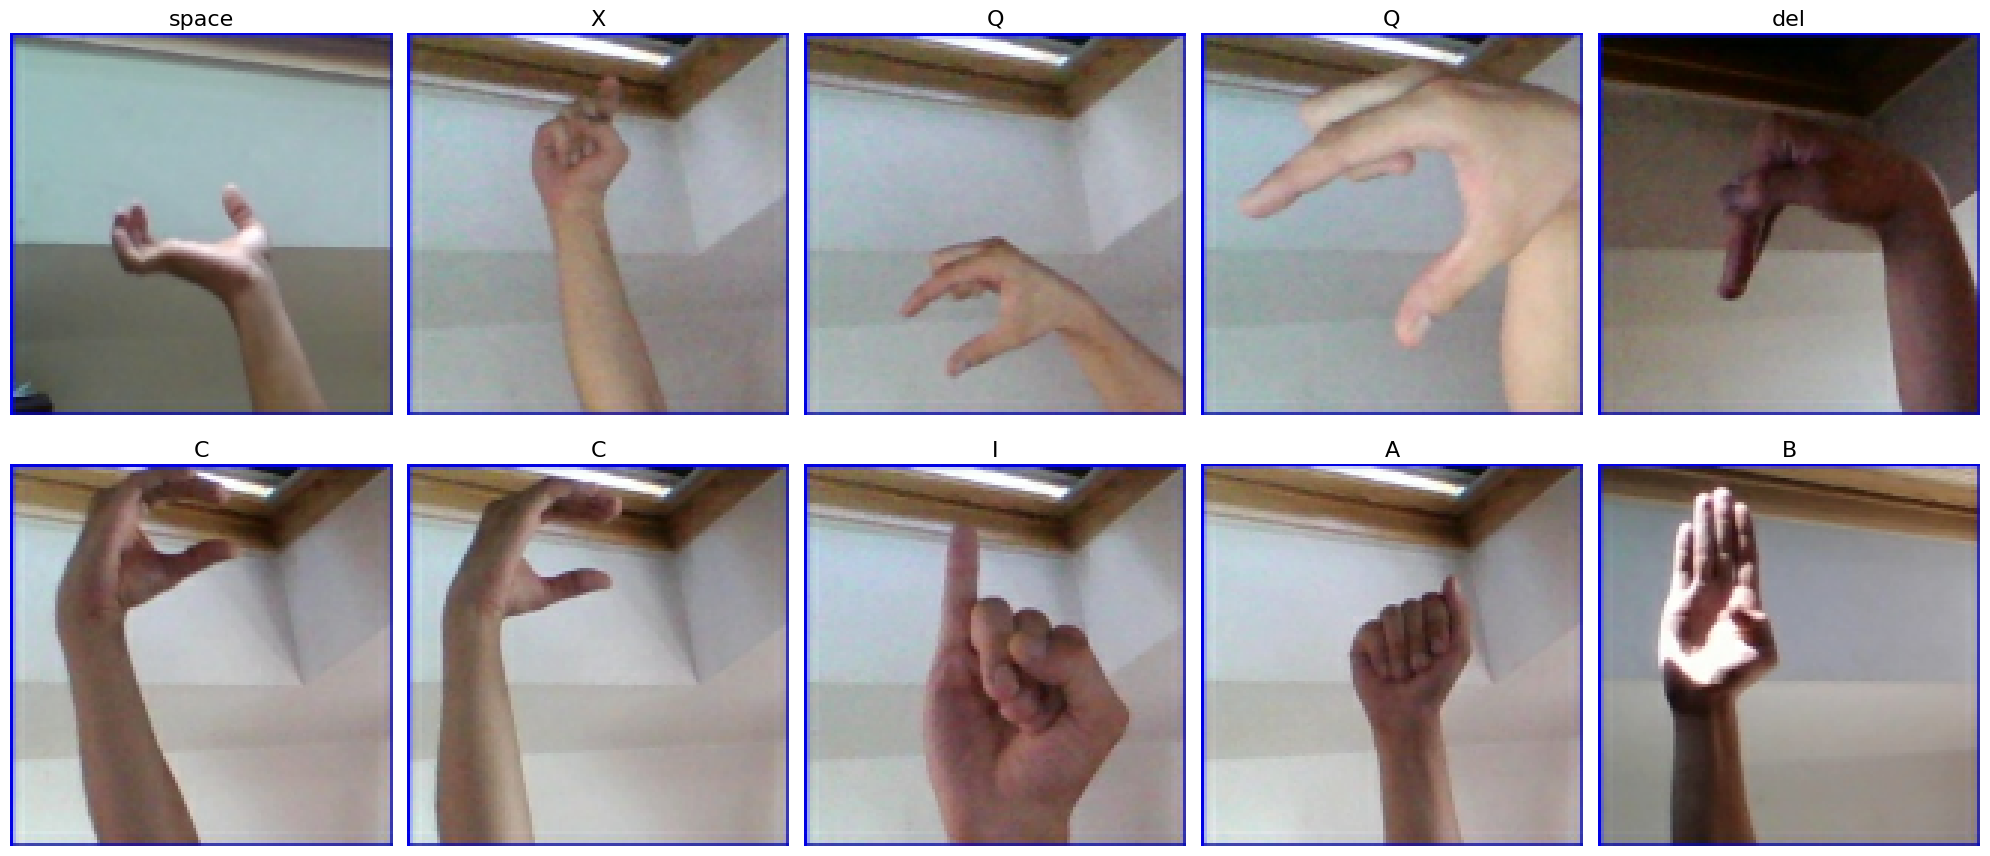

In [8]:
for x_batch, y_batch in train_ds.take(1):
    break

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_batch[i].numpy().astype('uint8'), interpolation='nearest')
    label_idx = np.argmax(y_batch[i])
    ax.set_title(class_names[label_idx], fontsize=16)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [9]:
num_classes = len(class_names)
idx_to_class = {i: name for i, name in enumerate(class_names)}

print('num_classes:', num_classes)
idx_to_class

num_classes: 29


{0: 'A',
 1: 'B',
 2: 'C',
 3: 'D',
 4: 'E',
 5: 'F',
 6: 'G',
 7: 'H',
 8: 'I',
 9: 'J',
 10: 'K',
 11: 'L',
 12: 'M',
 13: 'N',
 14: 'O',
 15: 'P',
 16: 'Q',
 17: 'R',
 18: 'S',
 19: 'T',
 20: 'U',
 21: 'V',
 22: 'W',
 23: 'X',
 24: 'Y',
 25: 'Z',
 26: 'del',
 27: 'nothing',
 28: 'space'}

## Build the model

In [10]:
model = Sequential([

    RandomRotation(10/360, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    RandomZoom(0.1),
    RandomTranslation(0.1, 0.1),
    Rescaling(1./255),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(2,2),
    Dropout(0.25),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 128, 128, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,225,373 (50.45 MB)

 Trainable params: 13,224,477 (50.45 MB)

 Non-trainable params: 896 (3.50 KB)

## Train


In [11]:
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
checkpoint = ModelCheckpoint('sign_language_cnn_model.keras', save_best_only=True, monitor='val_accuracy')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=45,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/45


E0000 00:00:1789881474.914840      59 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1088/1088 ━━━━━━━━━━━━━━━━━━━━ 189s 167ms/step - accuracy: 0.0660 - loss: 3.4071 - val_accuracy: 0.0862 - val_loss: 3.0854 - learning_rate: 0.0010
Epoch 2/45
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 175s 161ms/step - accuracy: 0.0964 - loss: 3.0828 - val_accuracy: 0.1198 - val_loss: 4.7406 - learning_rate: 0.0010
Epoch 3/45
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 173s 159ms/step - accuracy: 0.1178 - loss: 2.9794 - val_accuracy: 0.1578 - val_loss: 2.7385 - learning_rate: 0.0010
Epoch 4/45
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 172s 158ms/step - accuracy: 0.1580 - loss: 2.7662 - val_accuracy: 0.2055 - val_loss: 3.6901 - learning_rate: 0.0010
Epoch 5/45
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 171s 157ms/step - accuracy: 0.2455 - loss: 2.4311 - val_accuracy: 0.3517 - val_loss: 2.0652 - learning_rate: 0.0010
Epoch 6/45
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 170s 157ms/step - accuracy: 0.3313 - loss: 2.0648 - val_accuracy: 0.3899 - val_loss: 2.0568 - learning_rate: 0.0010
Epoch 7/45
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 171s 157ms/step - acc

## Training curves

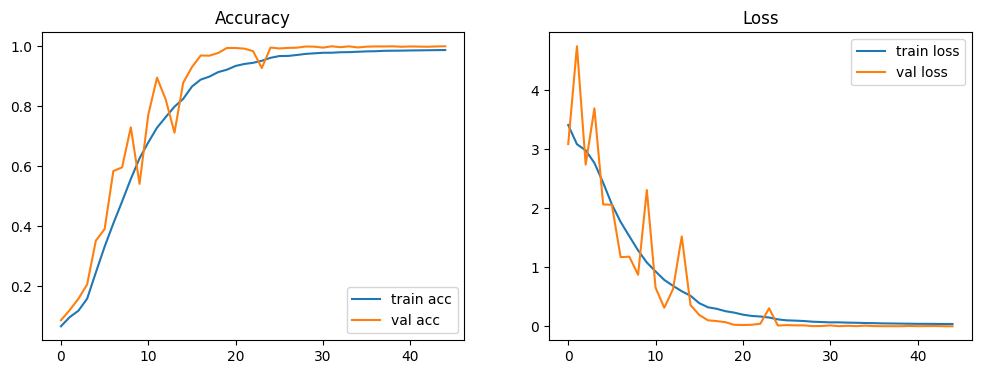

In [12]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss')

plt.show()

## Evaluate

In [13]:
test_loss, test_acc = model.evaluate(val_ds)
print('Validation accuracy:', test_acc)

y_true = []
y_pred_labels = []

for x_batch, y_batch in val_ds:
    preds = model.predict(x_batch, verbose=0)
    y_pred_labels.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))

y_true = np.array(y_true)
y_pred_labels = np.array(y_pred_labels)

target_names = [idx_to_class[i] for i in range(num_classes)]
print(classification_report(
    y_true, y_pred_labels,
    labels=list(range(num_classes)),
    target_names=target_names,
    zero_division=0
))

missing = sorted(set(range(num_classes)) - set(y_true))
if missing:
    print('\nWarning: these classes had ZERO images in the validation set:',
          [idx_to_class[i] for i in missing])

272/272 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9994 - loss: 0.0021
Validation accuracy: 0.9994252920150757
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       623
           B       1.00      1.00      1.00       634
           C       1.00      1.00      1.00       601
           D       1.00      1.00      1.00       643
           E       1.00      1.00      1.00       548
           F       1.00      1.00      1.00       646
           G       1.00      1.00      1.00       612
           H       1.00      1.00      1.00       626
           I       1.00      1.00      1.00       607
           J       1.00      1.00      1.00       626
           K       1.00      1.00      1.00       553
           L       1.00      1.00      1.00       593
           M       0.99      1.00      1.00       594
           N       1.00      0.99      1.00       555
           O       1.00      1.00      1.00       595
           P       

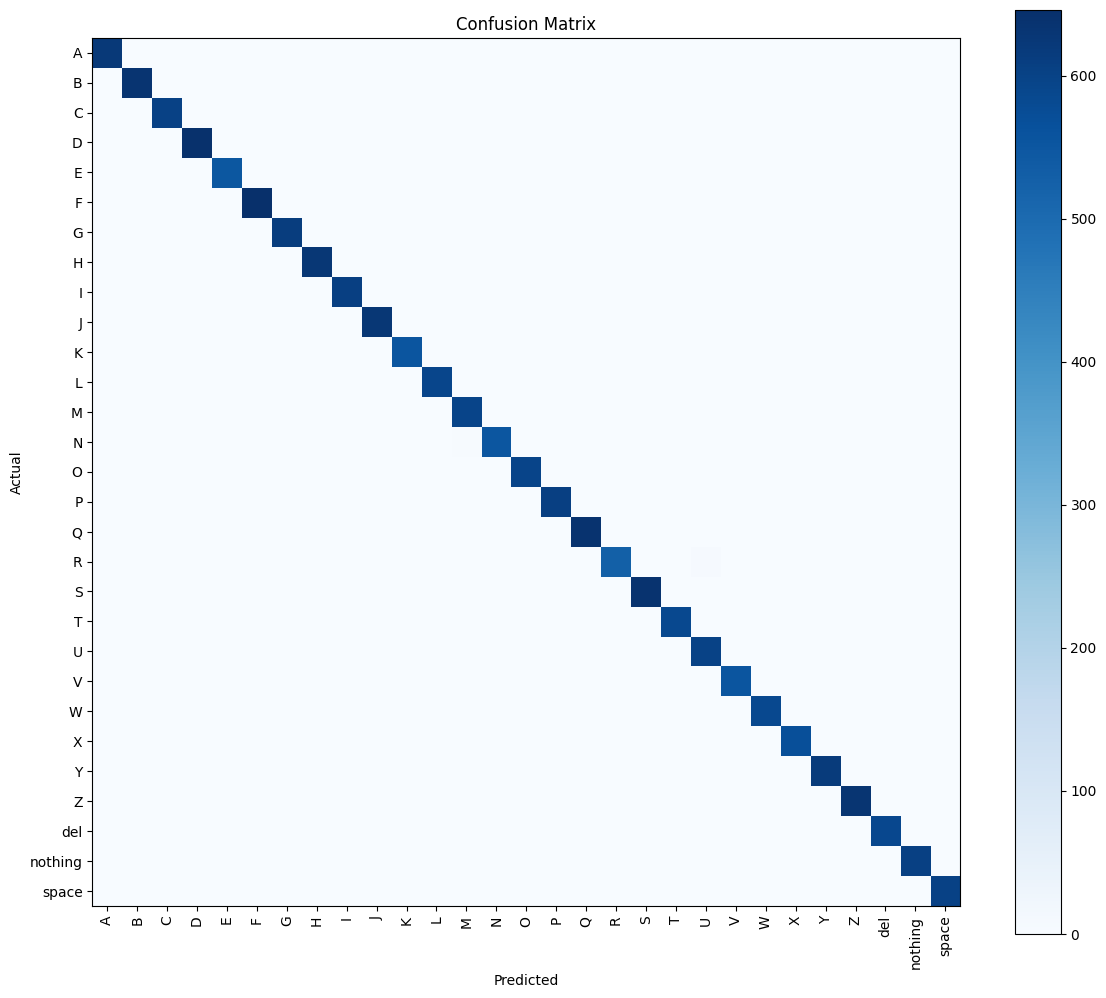

In [14]:
cm = confusion_matrix(y_true, y_pred_labels, labels=list(range(num_classes)))

plt.figure(figsize=(14, 12))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(num_classes), [idx_to_class[i] for i in range(num_classes)], rotation=90)
plt.yticks(range(num_classes), [idx_to_class[i] for i in range(num_classes)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Label map



In [15]:
label_map = idx_to_class
label_map_df = pd.DataFrame(sorted(label_map.items()), columns=['index', 'class'])
label_map_df.to_excel('label_map.xlsx', index=False, engine='openpyxl')
label_map

{0: 'A',
 1: 'B',
 2: 'C',
 3: 'D',
 4: 'E',
 5: 'F',
 6: 'G',
 7: 'H',
 8: 'I',
 9: 'J',
 10: 'K',
 11: 'L',
 12: 'M',
 13: 'N',
 14: 'O',
 15: 'P',
 16: 'Q',
 17: 'R',
 18: 'S',
 19: 'T',
 20: 'U',
 21: 'V',
 22: 'W',
 23: 'X',
 24: 'Y',
 25: 'Z',
 26: 'del',
 27: 'nothing',
 28: 'space'}

## The GUI app (Gradio)

In [16]:
START_HOUR = 18  # 6 PM
END_HOUR = 22    # 10 PM

ENFORCE_TIME_RESTRICTION = True

IST_OFFSET = datetime.timedelta(hours=5, minutes=30)

def local_now():
    return datetime.datetime.utcnow() + IST_OFFSET

KNOWN_WORDS = ["HELLO", "YES", "NO", "THANKS", "PLEASE", "LOVE"]

prediction_log = []  # list of dicts, exported to excel later

def is_within_operating_hours():
    if not ENFORCE_TIME_RESTRICTION:
        return True
    now = local_now()
    return START_HOUR <= now.hour < END_HOUR

def classify_frame(image):
    """image is a numpy array (RGB) coming from gradio. returns (letter, confidence) or (None, 0) if no image."""
    if image is None:
        return None, 0.0

    h, w = image.shape[:2]
    side = min(h, w)
    y0 = (h - side) // 2
    x0 = (w - side) // 2
    cropped = image[y0:y0 + side, x0:x0 + side]

    resized = cv2.resize(cropped, (IMG_SIZE, IMG_SIZE))
    arr = resized.astype('float32')
    arr = arr.reshape(1, IMG_SIZE, IMG_SIZE, 3)

    pred = model.predict(arr, verbose=0)
    idx = int(np.argmax(pred))
    confidence = float(np.max(pred)) * 100
    letter = label_map[idx]
    return letter, confidence


def log_prediction(source, letter, confidence, word_so_far=""):
    prediction_log.append({
        "timestamp": local_now().strftime("%Y-%m-%d %H:%M:%S"),
        "source": source,
        "predicted_letter": letter,
        "confidence_percent": round(confidence, 2),
        "word_so_far": word_so_far,
    })

In [17]:
def predict_upload(image):
    if not is_within_operating_hours():
        return f"Model only works between {START_HOUR}:00 and {END_HOUR}:00. Try again later."

    letter, confidence = classify_frame(image)
    if letter is None:
        return "Please upload an image first."

    log_prediction("upload", letter, confidence)

    if letter == "nothing":
        return f"No hand detected in this image ({confidence:.2f}% confidence)."

    return f"Predicted letter: {letter} ({confidence:.2f}% confidence)"

In [18]:
CONFIDENCE_THRESHOLD = 50.0
SMOOTHING_WINDOW = 7


def stream_predict(frame, history):
    """called continuously while the webcam is streaming.

    `history` is a gr.State holding the last few confident predictions (a
    plain list of letters) - Gradio keeps a separate copy of this per
    browser session, so different users streaming at the same time don't
    share or clobber each other's smoothing buffer.

    returns the text to show, the updated history (fed back into the next
    call), and the current smoothed letter (fed into last_letter_state, so
    the "Add Current Letter" button can just use exactly what's on screen
    instead of re-classifying the frame itself).
    """
    if not is_within_operating_hours():
        return f"Closed - model only runs {START_HOUR}:00 to {END_HOUR}:00", history, None

    letter, confidence = classify_frame(frame)
    if letter is None:
        return "...", history, None

    history = list(history) if history else []

    if confidence >= CONFIDENCE_THRESHOLD:
        history.append(letter)
    history = history[-SMOOTHING_WINDOW:]

    if not history:
        return f"Uncertain (best guess: {letter}, {confidence:.0f}%)", history, None

    smoothed_letter = Counter(history).most_common(1)[0][0]
    return f"{smoothed_letter} (last frame confidence: {confidence:.0f}%)", history, smoothed_letter


def add_letter(letter, word_state):
    """called when the user clicks 'Add Letter to Word'.

    `letter` here is last_letter_state - the smoothed letter stream_predict
    already computed and is currently showing on screen - not a raw frame.
    This guarantees Add Letter always adds exactly what the user sees
    displayed, and skips re-running the model a second time for no reason.

    most predictions just get appended to the word, but a few are control
    gestures rather than letters: 'del' removes the last character (a
    sign-language backspace), 'space' inserts a space so you can spell
    more than one word, and 'nothing' (no hand in frame) is just ignored.
    """
    if not is_within_operating_hours():
        msg = f"Closed - model only runs {START_HOUR}:00 to {END_HOUR}:00"
        return word_state, word_state, msg

    if not letter:
        return word_state, word_state, "No stable sign yet - hold your hand steady in frame and try again."

    if letter == "nothing":
        log_prediction("realtime", letter, 100.0, word_state)
        return word_state, word_state, "No hand detected - show a sign to add a letter."

    if letter == "del":
        new_word = word_state[:-1]
        log_prediction("realtime", letter, 100.0, new_word)
        return new_word, new_word, "Deleted last character."

    if letter == "space":
        new_word = word_state + " "
        log_prediction("realtime", letter, 100.0, new_word)
        return new_word, new_word, "Added a space."

    new_word = word_state + letter
    log_prediction("realtime", letter, 100.0, new_word)

    if new_word.strip() in KNOWN_WORDS:
        status = f"That spells '{new_word.strip()}' - recognized as a known word!"
    else:
        status = f"Added '{letter}'. Known words: {', '.join(KNOWN_WORDS)}"

    return new_word, new_word, status

def clear_word():
    return "", "", ""

def export_log_to_excel():
    if not prediction_log:
        return None
    df = pd.DataFrame(prediction_log)
    out_path = "prediction_log.xlsx"
    df.to_excel(out_path, index=False, engine="openpyxl")
    return out_path


In [19]:
with gr.Blocks(title="Sign Language Detection") as demo:
    gr.Markdown("# Sign Language Detection")
    gr.Markdown(
        f"Model only runs between {START_HOUR}:00 and {END_HOUR}:00. "
        "Upload an image of a letter, or use the webcam tab and spell out one of the known words: "
        + ", ".join(KNOWN_WORDS)
        + ". Sign 'space' to add a space and 'del' to delete the last character."
    )

    with gr.Tab("Upload Image"):
        with gr.Row():
            with gr.Column():
                upload_img = gr.Image(type="numpy", label="Upload a hand sign image")
                upload_btn = gr.Button("Predict")
            with gr.Column():
                upload_out = gr.Textbox(label="Result")
        upload_btn.click(fn=predict_upload, inputs=upload_img, outputs=upload_out)

    with gr.Tab("Real-Time Video"):
        with gr.Row():
            with gr.Column():
                cam = gr.Image(sources=["webcam"], streaming=True, label="Webcam")
                with gr.Row():
                    add_btn = gr.Button("Add Current Letter to Word")
                    clear_btn = gr.Button("Clear Word")
            with gr.Column():
                live_letter = gr.Textbox(label="Current letter")
                word_box = gr.Textbox(label="Word spelled so far", interactive=False)
                status_box = gr.Textbox(label="Status", interactive=False)

        word_state = gr.State("")
     
        history_state = gr.State([])
        
        last_letter_state = gr.State(None)

        cam.stream(fn=stream_predict, inputs=[cam, history_state], outputs=[live_letter, history_state, last_letter_state])
        add_btn.click(fn=add_letter, inputs=[last_letter_state, word_state], outputs=[word_state, word_box, status_box])
        clear_btn.click(fn=clear_word, inputs=None, outputs=[word_state, word_box, status_box])

    gr.Markdown("---")
    export_btn = gr.Button("Export Prediction Log to Excel")
    export_file = gr.File(label="Download log")
    export_btn.click(fn=export_log_to_excel, inputs=None, outputs=export_file)

In [22]:
demo.launch(share=True, debug=False)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://3702608a3465e478f2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


When you're done, run `demo.close()` in a new cell to shut the app down.

In [23]:
demo.close()

Closing server running on port: 7860


## Insights

- The CNN predicts the corresponding **ASL sign/alphabet** from input images.
- The model recognizes **A–Z**, along with `space`, `del`, and `nothing`.
- Predicted letters can be combined to recognize selected **known words**.
- The system supports both **image upload and webcam/real-time video input** through the GUI.
- The time-based restriction allows the system to operate only during the specified period, such as **6 PM to 10 PM**.
- The Gradio GUI makes the system easy to use and allows users to view sign predictions and recognized words.

## Conclusion

The project successfully develops a **CNN-based Sign Language Detection System** for recognizing American Sign Language gestures. It predicts ASL alphabet signs, recognizes selected known words, and provides image upload and webcam/real-time video functionality through a Gradio GUI. The addition of time-based operation and model evaluation demonstrates a practical machine learning application.

## Future Scope

- Train the model on a larger and more diverse sign language dataset.
- Improve sign classification accuracy.
- Add recognition of complete words and sentences.
- Improve real-time webcam performance.
- Add confidence scores and prediction history.
- Support dynamic signs and continuous gesture sequences.
- Add more advanced deep-learning models such as transfer learning.
- Deploy the system using **Streamlit or Flask**.